In [25]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt
import numpy as np

In [26]:
df = pd.read_csv("global_power_plant_database.csv", low_memory = False)

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34936 entries, 0 to 34935
Data columns (total 36 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         34936 non-null  object 
 1   country_long                    34936 non-null  object 
 2   name                            34936 non-null  object 
 3   gppd_idnr                       34936 non-null  object 
 4   capacity_mw                     34936 non-null  float64
 5   latitude                        34936 non-null  float64
 6   longitude                       34936 non-null  float64
 7   primary_fuel                    34936 non-null  object 
 8   other_fuel1                     1944 non-null   object 
 9   other_fuel2                     276 non-null    object 
 10  other_fuel3                     92 non-null     object 
 11  commissioning_year              17447 non-null  float64
 12  owner                           

In [28]:
df.head()

,country,country_long,name,gppd_idnr,capacity_mw,latitude,longitude,primary_fuel,other_fuel1,other_fuel2,...,estimated_generation_gwh_2013,estimated_generation_gwh_2014,estimated_generation_gwh_2015,estimated_generation_gwh_2016,estimated_generation_gwh_2017,estimated_generation_note_2013,estimated_generation_note_2014,estimated_generation_note_2015,estimated_generation_note_2016,estimated_generation_note_2017
0,AFG,Afghanistan,Kajaki Hydroelectric Power Plant Afghanistan,GEODB0040538,33.0,32.322,65.1190,Hydro,NaN,NaN,...,123.77,162.90,97.39,137.76,119.50,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
1,AFG,Afghanistan,Kandahar DOG,WKS0070144,10.0,31.670,65.7950,Solar,NaN,NaN,...,18.43,17.48,18.25,17.70,18.29,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
2,AFG,Afghanistan,Kandahar JOL,WKS0071196,10.0,31.623,65.7920,Solar,NaN,NaN,...,18.64,17.58,19.10,17.62,18.72,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE,SOLAR-V1-NO-AGE
3,AFG,Afghanistan,Mahipar Hydroelectric Power Plant Afghanistan,GEODB0040541,66.0,34.556,69.4787,Hydro,NaN,NaN,...,225.06,203.55,146.90,230.18,174.91,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1
4,AFG,Afghanistan,Naghlu Dam Hydroelectric Power Plant Afghanistan,GEODB0040534,100.0,34.641,69.7170,Hydro,NaN,NaN,...,406.16,357.22,270.99,395.38,350.80,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1,HYDRO-V1


In [29]:
#Checking for Missing Coordinates
missing_coordinates = df[df["latitude"].isna() | df["longitude"].isna()]
print(f"Count of missing coordinates: {len(missing_coordinates)}")

Count of missing coordinates: 0


In [30]:
#Checking for Duplicates
duplicate_coordinates = df.duplicated(subset = ["latitude", "longitude", "name"])
print(f"Duplicate locations: {duplicate_coordinates.sum()}")

Duplicate locations: 98


In [31]:
#Checking for Outliers
#Removing extreme capacity outliers to reduce skew and improve data consistency
from scipy.stats import zscore

df["z_capacity"] = zscore(df["capacity_mw"], nan_policy="omit")
outliers = df[df["z_capacity"].abs() > 3]
print(f"Outliers detected: {len(outliers)}")

Outliers detected: 700


In [32]:
#Checking for Different Names at the Same Coordinates
spatial_dupes = df[df.duplicated(subset = ["latitude", "longitude"], keep = False)]
print(f"Plants sharing the same coordinates: {len(spatial_dupes)}")

Plants sharing the same coordinates: 1846


In [33]:
#Checking for Invalid Coordinates
invalid_coordinates = df[(df["latitude"] > 90) | (df["latitude"] < -90) |
                    (df["longitude"] > 180) | (df["longitude"] < -180)]
print(f"Count of invalid coordinate points: {len(invalid_coordinates)}")

Count of invalid coordinate points: 0


In [34]:
#Checking Null Island
null_island = df[(df["latitude"] == 0) & (df["longitude"] == 0)]
print(f"Plants at 0,0 (Null Island): {len(null_island)}")

Plants at 0,0 (Null Island): 0


In [35]:
#Checking 0 or Minus Capacity
zero_capacity = df[df["capacity_mw"] <= 0]
print(f"Plants with zero/negative capacity: {len(zero_capacity)}")

Plants with zero/negative capacity: 0


In [36]:
# Cleaning the Data
df_valid = df.dropna(subset = ["latitude", "longitude"])
df_valid = df_valid[(df_valid["latitude"].between(-90, 90)) &
                    (df_valid["longitude"].between(-180, 180))]

df_valid = df_valid.drop_duplicates(subset=["latitude", "longitude", "name"], keep="first")

df_valid = df_valid[df_valid["capacity_mw"] > 0]
df_valid = df_valid[df_valid["z_capacity"].abs() <= 3]

print(f"Final row count after data cleaning: {len(df_valid)}")
print(f"Data retention after cleaning: {len(df_valid)/len(df)*100:.2f}%")

Final row count after data cleaning: 34138
Data retention after cleaning: 97.72%


In [37]:
#Checking Global Renewable Capacity
renewable_fuels = ["Solar", "Wind", "Hydro", "Geothermal", "Biomass"]
df_valid = df_valid.copy()
df_valid["is_renewable"] = df_valid["primary_fuel"].isin(renewable_fuels)

renewable_capacity = df_valid.loc[df_valid["is_renewable"], "capacity_mw"].sum()
total_capacity = df_valid["capacity_mw"].sum()
renew_pct = (renewable_capacity / total_capacity) * 100

In [38]:
#Calculating Renewable Percentage by Country
df_valid["renewable_capacity_mw"] = df_valid["capacity_mw"].where(df_valid["is_renewable"], 0)

country_stats = df_valid.groupby("country_long").agg(
    total_mw=("capacity_mw", "sum"),
    renewable_mw=("renewable_capacity_mw", "sum")
)

country_stats["renew_share"] = (country_stats["renewable_mw"] / country_stats["total_mw"]) * 100

#Top 5 Greenest Countries - With at Least 1000MW Total Capacity to Avoid Outliers)
greenest = country_stats[country_stats["total_mw"] > 1000].sort_values("renew_share", ascending=False)

print("Top 5 Greenest Countries:")
print(greenest.head(5))

Top 5 Greenest Countries:
              total_mw  renewable_mw  renew_share
country_long                                     
Bhutan         1482.20       1482.20        100.0
Ethiopia       2153.90       2153.90        100.0
Iceland        2484.60       2484.60        100.0
Laos           3108.86       3108.86        100.0
Paraguay       1760.00       1760.00        100.0


In [39]:
#Identifying the Most Crowded Coordinates
crowded_spots = df_valid.groupby(["latitude", "longitude", "country_long"]).size().sort_values(ascending = False)

print("Top Crowded Locations:")
print(crowded_spots.head(3))

Top Crowded Locations:
latitude  longitude  country_long
-2.5213    121.3570  Indonesia       14
-23.6461  -46.6386   Brazil          11
 15.6620   78.2570   India           11
dtype: int64


In [40]:
#Checking the Most Crowded Coordinates' Exact Locations
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="geo_analyzer", timeout=10)

#Using try-except blocks to ensure the pipeline's resilience against network latency and service timeouts
try:
    location_Indonesia = geolocator.reverse("-2.5213, 121.3570")
    location_Spain = geolocator.reverse("36.0139, -5.6069")
    location_Brazil = geolocator.reverse("-23.6461, -46.6386")

    print(f"Indonesia: {location_Indonesia.address}")
    print(f"Spain: {location_Spain.address}")
    print(f"Brazil: {location_Brazil.address}")

except Exception as e:
    print(f"Geocoding failed: {e}")

#Indonesia (Sorowako): Confirmed as a major industrial nickel mining complex. High asset density is attributed to multiple captive power units serving a single integrated facility.
#Spain (Tarifa): Identified as a high-density wind energy corridor. Shared coordinates reflect centralized grid-connection points for massive regional wind farms.
#Brazil (São Paulo): Dense urban clusters indicate "Administrative Generalization," where multiple municipal units or backup generators are assigned to a single district coordinate.


Indonesia: Jalan Pongkia, Sorowako, Luwu Timur, Nikkel, Sulawesi Selatan, Sulawesi, 91984, Indonesia
Spain: 32,34, Calle Bailén, Cardenal Cisneros, Tarifa, Campo de Gibraltar, Cádiz, Andalucía, 11380, España
Brazil: Rua Anita Costa, Cidade Vargas, Jabaquara, São Paulo, Região Imediata de São Paulo, Região Metropolitana de São Paulo, Região Geográfica Intermediária de São Paulo, São Paulo, 04309-011, Brasil


In [41]:
#Creating GeoDataFrame
geometry = [Point(xy) for xy in zip(df_valid["longitude"], df_valid["latitude"])]
gdf = gpd.GeoDataFrame(df_valid, geometry=geometry)
gdf.crs = "EPSG:4326"

In [42]:
#Accessing "naturalearth_lowres"
world_url = "https://raw.githubusercontent.com/datasets/geo-boundaries-world-110m/master/countries.geojson"
world = gpd.read_file(world_url)

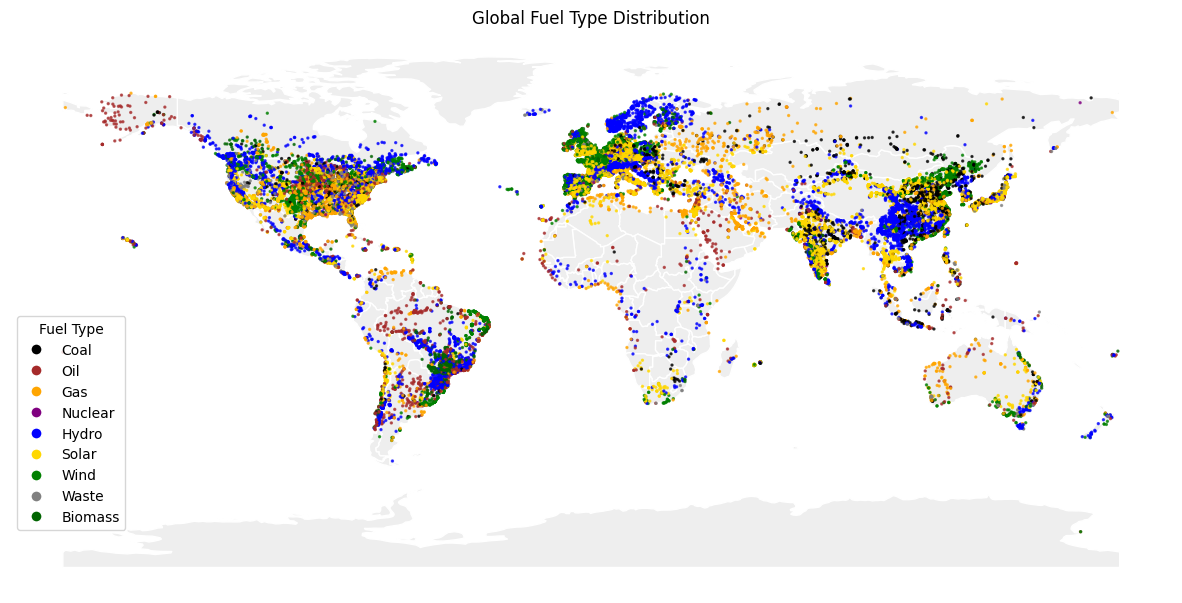

In [43]:
#Creating a Global Fuel Type Distribution Map
fuel_colors = {
    "Coal": "black",
    "Oil": "brown",
    "Gas": "orange",
    "Nuclear": "purple",
    "Hydro": "blue",
    "Solar": "gold",
    "Wind": "green",
    "Waste": "grey",
    "Biomass": "darkgreen"
}

fig, ax = plt.subplots(figsize=(15, 10))
world.plot(ax = ax, color = "#eeeeee", edgecolor = "white")

gdf.plot(ax=ax,
         color=[fuel_colors.get(x, "grey") for x in gdf["primary_fuel"]],
         markersize=2,
         alpha=0.7)

from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker = "o", color = "w", label = k,
                          markerfacecolor = v, markersize = 8) for k, v in fuel_colors.items()]

ax.legend(handles = legend_elements, loc = "lower left", title = "Fuel Type", bbox_to_anchor = (0, 0.1))

plt.title("Global Fuel Type Distribution")
plt.axis("off")
plt.show()